In [25]:
import os
from pathlib import Path
ROOT = "../" # Base directory relative to this notebook's location. Adjust if the notebook is moved
CSV_DIR = os.path.join(ROOT, "csv", "historical-data", "2015-2025")
STATS_DIR = os.path.join(ROOT, "csv", "stats", "2015-2025")
import json
JSON_DIR = os.path.join(ROOT, "json")

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import geopandas as gpd
MAPS_DIR = os.path.join(ROOT, "maps")
import contextily as ctx

from IPython.display import clear_output
import time

import sys
sys.path.append(ROOT)
import src.weather_stats as ws
from src.weather_data_download import download_station_data, cast_columns

### Updating stats

In [2]:
date_cutoff = "2025-12-31"  # Set to None to include all dates

rows = []
processed = 0

for filename in os.listdir(CSV_DIR):
    file_path = os.path.join(CSV_DIR, filename)

    # Ignore subfolders
    if not os.path.isfile(file_path):
        continue

    try:
        # Force indicativo as text
        df = pd.read_csv(file_path, dtype={"indicativo": str})

        # Parse fecha to datetime (coerce invalid -> NaT)
        if "fecha" in df.columns:
            df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

        # Filter by date_cutoff if provided
        if date_cutoff is not None and "fecha" in df.columns:
            cutoff_dt = pd.to_datetime(date_cutoff)
            df = df[df["fecha"].notna() & (df["fecha"] <= cutoff_dt)]

        # Skip files with no rows after filtering
        if df.empty:
            clear_output(wait=True)
            print(f"Skipping {filename}: no rows after date filter")
            processed += 1
            time.sleep(0.002)
            continue

        clear_output(wait=True)
        print(f"Processing {filename}... ({processed + 1}/{len(os.listdir(CSV_DIR))})")
        time.sleep(0.01)

        rows.append(
            {
                "indicativo": str(df["indicativo"].iloc[0]) if "indicativo" in df.columns else None,
                "nombre": df["nombre"].iloc[0] if "nombre" in df.columns else None,
                "altitud": df["altitud"].iloc[0] if "altitud" in df.columns else None,
                "provincia": df["provincia"].iloc[0] if "provincia" in df.columns else None,
                "num_records": len(df),
                "avg_tmin": ws.safe_stat(df, "tmin", lambda s: s.mean()),
                "avg_tmax": ws.safe_stat(df, "tmax", lambda s: s.mean()),
                "avg_prec": ws.safe_stat(df, "prec", lambda s: s.mean()),
                "avg_velmedia": ws.safe_stat(df, "velmedia", lambda s: s.mean()),
                "std_tmed": ws.safe_stat(df, "tmed", lambda s: s.std()),
                "longest_gap_days": ws.calculate_longest_gap_days(df),
            }
        )

        processed += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

stations_df = pd.DataFrame(rows)

# Ensure consistent type before sorting
stations_df["indicativo"] = stations_df["indicativo"].astype(str)

stations_df = (
    stations_df
    .sort_values("indicativo")
    .reset_index(drop=True)
)

print(f"Processed {len(stations_df)} stations.")
display(stations_df.head())

Processing 1078I_hist.csv... (778/778)
Processed 778 stations.


,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
0,0009X,ALFORJA,406,TARRAGONA,3946,10.191411,21.297034,1.502602,3.106684,6.195665,19
1,0016A,REUS AEROPUERTO,71,TARRAGONA,4018,11.554893,22.710324,1.240720,3.449813,6.325553,122
2,0034X,VALLS,233,TARRAGONA,4018,10.709315,22.598406,1.166752,NaN,6.388363,1
3,0042Y,TARRAGONA,55,TARRAGONA,4001,13.231322,22.422759,1.266323,1.716104,5.690694,10
4,0061X,PONTONS,632,BARCELONA,3869,8.285392,19.659497,1.547828,3.428817,6.133330,48


In [3]:
stations_df.to_csv(os.path.join(ROOT, "csv", "stats", "2015-2025", "weather-station-stats.csv"), index=False)

### Loading stats

In [4]:
stations_df = pd.read_csv(os.path.join(ROOT, "csv", "stats", "2015-2025", "weather-station-stats.csv"))

### Descriptive analysis and validations

Highest Average High Temperature

In [5]:
# Highest Average High Temperature
highest_tmax = stations_df.sort_values("avg_tmax", ascending=False).head(15)
display(
    highest_tmax.style
    .set_properties(subset=["avg_tmax"], **{"background-color": "#ff9999", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
376,5361X,MONTORO,155,CORDOBA,3969,10.852928,26.808681,1.296790,1.491020,7.559993,14
752,C628B,"LA ALDEA DE SAN NICOLÁS, TASARTE",318,LAS PALMAS,3998,17.072287,26.796870,0.283123,3.901426,3.875556,6
408,5790Y,"SEVILLA, TABLADA",9,SEVILLA,3808,13.410316,26.477658,1.248692,1.852495,6.383344,4
379,5402,CÓRDOBA AEROPUERTO,90,CORDOBA,4018,11.485282,26.472293,1.374153,2.520339,7.352312,4
348,4541X,EL GRANADO,60,HUELVA,4004,12.075076,26.371407,1.081634,nan,6.542351,6
489,7218Y,TOTANA,281,MURCIA,2440,14.444691,26.366049,0.809952,2.305558,6.297749,4
398,5641X,ÉCIJA,130,SEVILLA,3982,11.997850,26.320829,1.186834,2.274495,7.121541,29
401,5702X,CARMONA,50,SEVILLA,3950,12.569070,26.303992,1.230095,2.851461,6.722788,22
406,5783,SEVILLA AEROPUERTO,34,SEVILLA,4018,13.394486,26.300301,1.273817,3.251057,6.751988,8
484,7178I,MURCIA,62,MURCIA,4018,13.988751,26.270383,0.906622,2.612350,6.532119,0


Lowest Average High Temperature

In [6]:
# Lowest Average High Temperature
lowest_tmax = stations_df.sort_values("avg_tmax", ascending=True).head(15)
display(lowest_tmax.style.set_properties(subset=["avg_tmax"], **{"background-color": "#829cd4", "color": "black"}))

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
627,9677,PORT AINÉ,2410,LLEIDA,2079,0.553264,6.272361,nan,5.219702,6.911484,15
662,9988B,CAP DE VAQUÈIRA,2467,LLEIDA,2470,0.160870,6.399630,nan,4.165305,7.010648,861
645,9839V,"CERLER, COGULLA",2374,HUESCA,2240,1.533571,7.970580,2.378339,3.501656,6.499647,0
390,5516D,SIERRA NEVADA 'RADIOTELESCOPIO',2856,GRANADA,1619,2.569913,8.387469,nan,5.271178,7.175531,6
70,1167G,"MIRADOR DEL CABLE, PARQUE NACIONAL PICOS DE EUROPA",1910,CANTABRIA,1396,3.176285,9.491189,2.751794,5.945393,6.297862,540
71,1167J,"CORISCAO, PARQUE NACIONAL PICOS DE EUROPA",1722,CANTABRIA,1245,3.822808,9.687013,2.684106,3.381878,6.241866,531
643,9814I,"TORLA-ORDESA, EL CEBOLLAR",1905,HUESCA,2239,3.932127,11.152011,3.550690,2.929964,6.575147,1
188,2491C,"LA COVATILLA, ESTACIÓN DE ESQUÍ",1960,SALAMANCA,3602,3.647256,11.282447,3.623028,5.102521,6.792635,250
85,1221D,PAJARES-VALGRANDE,1480,ASTURIAS,3912,4.142872,11.307700,4.243733,2.861871,5.798280,27
603,9451F,"PANTICOSA, PETROSOS",1850,HUESCA,2207,4.652474,11.373706,3.743284,3.086475,6.676647,9


Highest Average Low Temperature

In [7]:
# Highest Average Low Temperature
highest_tmin = stations_df.sort_values("avg_tmin", ascending=False).head(15)

display(
    highest_tmin.style
    .set_properties(subset=["avg_tmin"], **{"background-color": "#f07d12", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
776,C929I,HIERRO AEROPUERTO,32,SANTA CRUZ DE TENERIFE,4018,19.798804,23.751719,0.355310,6.546393,2.279608,2
728,C329Z,SAN SEBASTIÁN DE LA GOMERA,15,STA. CRUZ DE TENERIFE,4012,19.597332,24.980902,0.264973,3.429603,2.849779,132
765,C659M,"LAS PALMAS DE GRAN CANARIA, PL. DE LA FERIA",15,LAS PALMAS,3957,19.542143,23.664956,0.421942,2.197720,2.403555,68
753,C629Q,"MOGÁN, PUERTO RICO",10,LAS PALMAS,4009,19.475426,23.872618,0.105024,3.001298,2.333612,2
748,C619X,AGAETE,5,LAS PALMAS,3996,19.339205,24.232501,0.294051,4.862365,2.657552,14
739,C449C,STA.CRUZ DE TENERIFE,36,SANTA CRUZ DE TENERIFE,3992,19.237989,25.442216,0.524797,3.006193,2.956515,4
715,C129V,FUENCALIENTE,19,STA. CRUZ DE TENERIFE,4015,19.227732,24.598342,0.424298,6.437700,2.349511,5
718,C229J,PÁJARA,15,LAS PALMAS,3904,19.159007,25.369942,0.152380,3.163248,3.115629,19
777,C939T,"FRONTERA, SABINOSA",20,STA. CRUZ DE TENERIFE,4018,18.982667,23.948751,0.403112,3.218932,2.419363,2
756,C639M,"MASPALOMAS, C. INSULAR TURISMO",45,LAS PALMAS,3984,18.882465,25.470926,0.166251,2.766817,2.959685,7


Highest Average Low Temperature excluding Canary Islands

In [8]:
# Highest Average Low Temperature excluding Canary Islands
highest_tmin_no_canary = stations_df[~stations_df["provincia"].str.contains("TENERIFE|PALMAS", na=False)] \
    .sort_values("avg_tmin", ascending=False).head(15)
display(highest_tmin_no_canary.style.set_properties(subset=["avg_tmin"], **{"background-color": "#f07d12", "color": "black"}))

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
462,6329X,CABO DE GATA,42,ALMERIA,3995,17.644254,22.544842,0.375596,4.914691,4.843514,46
686,B569X,CAPDEPERA,57,BALEARES,3810,16.726951,22.702501,1.239026,4.657297,5.476745,54
426,6000A,MELILLA,52,MELILLA,4018,16.584028,23.129523,0.772432,3.175529,4.878847,3
421,5973,CÁDIZ,2,CADIZ,4018,16.504610,22.470563,1.279965,4.373068,4.775340,3
445,6175X,RINCÓN DE LA VICTORIA,7,MALAGA,3991,16.411200,25.664252,0.991313,nan,4.999410,84
438,6083X,MARBELLA,2,MALAGA,3990,16.374379,21.745763,1.039401,3.988146,4.218321,184
358,5000C,CEUTA,87,CEUTA,4018,16.353425,22.351806,1.775137,2.943644,4.456515,1
446,6199X,VÉLEZ-MÁLAGA,41,MALAGA,1269,15.999513,26.203490,0.891555,2.479310,5.331916,18
439,6088X,TORREMOLINOS,85,MALAGA,4018,15.987337,23.711558,1.189000,1.626595,5.071749,32
468,7012C,CARTAGENA,17,MURCIA,3831,15.945898,23.277898,0.720871,1.878338,5.666382,180


Lowest Average Low Temperature

In [9]:
# Lowest Average Low Temperature
lowest_tmin = stations_df.sort_values("avg_tmin", ascending=True).head(15)
display(lowest_tmin.style.set_properties(subset=["avg_tmin"], **{"background-color": "#cacbf1", "color": "black"}))

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
662,9988B,CAP DE VAQUÈIRA,2467,LLEIDA,2470,0.160870,6.399630,nan,4.165305,7.010648,861
627,9677,PORT AINÉ,2410,LLEIDA,2079,0.553264,6.272361,nan,5.219702,6.911484,15
645,9839V,"CERLER, COGULLA",2374,HUESCA,2240,1.533571,7.970580,2.378339,3.501656,6.499647,0
262,3319D,PUERTO DEL PICO,1285,AVILA,4006,1.562333,16.981261,4.121515,2.497148,6.075913,12
201,2630X,PUERTO DE SAN ISIDRO,1510,LEON,3247,2.225946,11.940438,3.001553,3.819876,5.915218,168
621,9590D,CAP DE REC,1940,LLEIDA,2594,2.268421,11.504413,nan,1.573526,6.339761,33
210,2766E,"SANABRIA, ROBLEDA-CERVANTES",933,ZAMORA,4010,2.486585,18.196329,2.343271,0.994755,5.907095,6
390,5516D,SIERRA NEVADA 'RADIOTELESCOPIO',2856,GRANADA,1619,2.569913,8.387469,nan,5.271178,7.175531,6
70,1167G,"MIRADOR DEL CABLE, PARQUE NACIONAL PICOS DE EUROPA",1910,CANTABRIA,1396,3.176285,9.491189,2.751794,5.945393,6.297862,540
166,2192C,CUÉLLAR,795,SEGOVIA,4011,3.179156,20.857859,1.262075,2.567183,6.895150,6


Highest Average Precipitation

In [10]:
# Highest Average Precipitation
highest_prec = stations_df.sort_values("avg_prec", ascending=False).head(15)
display(
    highest_prec.style
    .set_properties(subset=["avg_prec"], **{"background-color": "#a1cfff", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
121,1476R,"ROIS, CASAS DO PORTO",210,A CORUÑA,4002,10.288804,19.186653,8.022445,nan,4.792630,22
111,1406X,MAZARICOS,340,A CORUÑA,4008,9.466108,17.429444,7.273212,nan,4.591426,6
124,1489A,A LAMA,395,PONTEVEDRA,4009,8.400750,18.847787,6.743155,2.254848,5.310828,7
141,1696O,BEARIZ,610,OURENSE,4012,5.221307,19.100426,5.920351,nan,5.412148,4
109,1399,VIMIANZO,287,A CORUÑA,4011,9.485546,17.621830,5.811932,nan,4.312485,3
118,1468X,A ESTRADA,269,PONTEVEDRA,3991,9.217659,19.520458,5.708678,nan,5.158728,32
37,1021X,"ERRENTERIA, AÑARBE",165,GIPUZKOA,4005,9.920635,19.808993,5.530501,1.527946,5.449358,6
36,1014A,DONOSTIA / SAN SEBASTIÁN AEROPUERTO,4,GIPUZKOA,4018,11.936089,20.231793,5.365958,2.966550,5.327755,2
145,1719,A CAÑIZA,560,PONTEVEDRA,4007,8.767476,18.593615,5.345065,nan,5.407742,5
34,1010X,BERA,54,NAVARRA,3878,9.661959,20.006349,5.305192,1.129283,5.619405,140


Lowest average precipitation

In [11]:
# Lowest Avg Precipitation
lowest_prec = (stations_df.dropna(subset=["avg_prec"]).sort_values("avg_prec", ascending=True).head(15))

display(
    lowest_prec.style
    .set_properties(subset=["avg_prec"], **{"background-color": "#e2d40e", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
753,C629Q,"MOGÁN, PUERTO RICO",10,LAS PALMAS,4009,19.475426,23.872618,0.105024,3.001298,2.333612,2
754,C629X,"MOGÁN, PUERTO",10,LAS PALMAS,4002,18.352504,25.615942,0.125840,3.031033,2.592615,5
719,C239N,"TUINEJE,PUERTO GRAN TARAJAL",1,LAS PALMAS,3985,18.366540,25.465099,0.131555,4.184677,3.307574,5
769,C689E,MASPALOMAS,6,LAS PALMAS,3857,17.888151,24.404033,0.133236,3.273361,2.499024,1854
718,C229J,PÁJARA,15,LAS PALMAS,3904,19.159007,25.369942,0.152380,3.163248,3.115629,19
709,C019V,YAIZA PLAYA BLANCA,6,LAS PALMAS,4003,18.330284,24.055677,0.160738,4.220417,2.784828,28
756,C639M,"MASPALOMAS, C. INSULAR TURISMO",45,LAS PALMAS,3984,18.882465,25.470926,0.166251,2.766817,2.959685,7
721,C249I,FUERTEVENTURA AEROPUERTO,25,LAS PALMAS,4018,18.565228,24.675966,0.174307,6.124431,2.867074,3
757,C639U,"SAN BARTOLOME TIRAJANA, EL MATORRAL",41,LAS PALMAS,3995,17.943218,25.766153,0.205797,5.274712,3.151640,6
770,C839X,LA GRACIOSA,19,LAS PALMAS,3857,18.084447,24.271789,0.227521,6.107964,2.595470,45


Lowest average precipitation excluding Canary Islands

In [12]:
# Lowest average precipitation excluding Canary Islands
lowest_prec_no_canary = (
    stations_df[~stations_df["provincia"].str.contains("TENERIFE|PALMAS", na=False)]
    .dropna(subset=["avg_prec"])
    .sort_values("avg_prec", ascending=True)
    .head(20)
)
display(
    lowest_prec_no_canary.style.set_properties(subset=["avg_prec"], **{"background-color": "#e2d40e", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
457,6293X,ROQUETAS DE MAR,3,ALMERIA,3487,14.456166,23.054294,0.311435,4.241083,5.101301,265
462,6329X,CABO DE GATA,42,ALMERIA,3995,17.644254,22.544842,0.375596,4.914691,4.843514,46
456,6291B,EL EJIDO,98,ALMERIA,4018,15.818471,25.462453,0.478198,nan,5.325853,30
461,6325O,ALMERÍA AEROPUERTO,21,ALMERIA,4018,15.643498,24.199826,0.542604,4.506808,5.601425,1
360,5047E,BAZA,785,GRANADA,3740,7.635839,23.538453,0.562362,3.082310,7.436066,58
464,6364X,ALBOX,508,ALMERIA,3983,12.923632,25.402573,0.595270,3.505418,6.570722,38
361,5051X,HUÉSCAR,1100,GRANADA,923,6.497584,21.254647,0.606918,2.381998,7.846587,386
487,7209,LORCA,312,MURCIA,3992,12.103551,25.163040,0.610312,1.292999,6.625150,36
463,6340X,GARRUCHA,28,ALMERIA,4016,15.584493,22.729936,0.624570,4.044829,5.270353,42
466,7002Y,ÁGUILAS,32,MURCIA,4017,15.644417,24.102742,0.627207,2.516725,5.430447,3


Highest average wind speed

In [13]:
# Highest average wind speed
highest_wind = stations_df.sort_values("avg_velmedia", ascending=False).head(15)
display(
    highest_wind.style
    .set_properties(subset=["avg_velmedia"], **{"background-color": "#ff99f7", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
102,1351,ESTACA DE BARES,90,A CORUÑA,4001,12.590533,17.102705,2.071216,8.201438,3.424762,32
698,B800X,"LA MOLA, MAÓ",78,ILLES BALEARS,3836,15.601392,21.974161,0.926866,8.161765,5.426911,32
760,C649I,GRAN CANARIA AEROPUERTO,24,LAS PALMAS,4018,18.757187,24.890443,0.332193,7.578954,2.825290,11
734,C430E,IZAÑA,2369,SANTA CRUZ DE TENERIFE,4018,7.001916,14.889423,0.669635,7.005647,5.886677,0
723,C314Z,"VALLEHERMOSO, ALTO IGUALERO",1474,STA. CRUZ DE TENERIFE,3894,10.420515,17.708327,1.232633,6.972889,6.070186,60
108,1393,CABO VILÁN,50,A CORUÑA,3845,11.934240,16.847548,3.293101,6.852921,3.158834,87
110,1400,FISTERRA,230,A CORUÑA,3829,11.859386,16.967813,2.651779,6.753172,3.756634,173
776,C929I,HIERRO AEROPUERTO,32,SANTA CRUZ DE TENERIFE,4018,19.798804,23.751719,0.355310,6.546393,2.279608,2
715,C129V,FUENCALIENTE,19,STA. CRUZ DE TENERIFE,4015,19.227732,24.598342,0.424298,6.437700,2.349511,5
733,C429I,TENERIFE SUR AEROPUERTO,64,SANTA CRUZ DE TENERIFE,4018,18.210140,26.060601,0.233845,6.249837,2.938617,2


Highest average wind speed excluding Canary Islands

In [14]:
# Highest average wind speed excluding Canary Islands
highest_wind_no_canary = stations_df[~stations_df["provincia"].str.contains("TENERIFE|PALMAS", na=False)] \
    .sort_values("avg_velmedia", ascending=False).head(15)
display(
    highest_wind_no_canary.style
    .set_properties(subset=["avg_velmedia"], **{"background-color": "#ff99f7", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
102,1351,ESTACA DE BARES,90,A CORUÑA,4001,12.590533,17.102705,2.071216,8.201438,3.424762,32
698,B800X,"LA MOLA, MAÓ",78,ILLES BALEARS,3836,15.601392,21.974161,0.926866,8.161765,5.426911,32
108,1393,CABO VILÁN,50,A CORUÑA,3845,11.934240,16.847548,3.293101,6.852921,3.158834,87
110,1400,FISTERRA,230,A CORUÑA,3829,11.859386,16.967813,2.651779,6.753172,3.756634,173
427,6001,TARIFA,45,CADIZ,3963,15.429862,21.096223,1.549440,6.106676,4.278878,14
70,1167G,"MIRADOR DEL CABLE, PARQUE NACIONAL PICOS DE EUROPA",1910,CANTABRIA,1396,3.176285,9.491189,2.751794,5.945393,6.297862,540
681,B398A,"CABRERA, PARQUE NACIONAL DE CABRERA",165,BALEARES,2157,15.944403,21.003621,0.923024,5.416760,5.303834,1283
613,9550C,"ANDORRA, HORCALLANA",762,TERUEL,3991,9.448778,19.495449,0.923207,5.304829,7.109703,5
390,5516D,SIERRA NEVADA 'RADIOTELESCOPIO',2856,GRANADA,1619,2.569913,8.387469,nan,5.271178,7.175531,6
627,9677,PORT AINÉ,2410,LLEIDA,2079,0.553264,6.272361,nan,5.219702,6.911484,15


Lowest average wind speed

In [15]:
# Lowest average wind speed
lowest_wind = (
    stations_df.dropna(subset=["avg_velmedia"])
    .sort_values("avg_velmedia", ascending=True)
    .head(15)
)
display(
    lowest_wind.style
    .set_properties(subset=["avg_velmedia"], **{"background-color": "#99ff99", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
23,0360X,LES PLANES D'HOSTOLES,337,GIRONA,3983,6.736148,21.549130,2.143379,0.715266,6.583946,22
429,6040X,CORTES DE LA FRONTERA,315,MALAGA,3977,11.757392,23.583519,2.228009,0.757249,5.994224,48
142,1700X,O CARBALLIÑO,400,OURENSE,3998,7.298860,20.583181,3.039341,0.778147,5.970272,7
670,B103B,ANDRATX - SANT ELM,52,BALEARES,2747,13.297273,23.105930,1.091874,0.851098,5.875937,12
667,B013X,"ESCORCA, LLUC",490,ILLES BALEARS,4008,9.212264,20.764165,3.012656,0.877038,6.282779,4
33,1002Y,"BAZTAN, IRURITA",183,NAVARRA,3944,8.125762,19.824642,4.042930,0.914735,6.086550,68
604,9453X,"BIESCAS, EMBALSE DE BÚBAL",1100,HUESCA,4016,4.643407,16.720125,3.864198,0.916663,6.490479,2
389,5515X,GRANADA-CARTUJA,775,GRANADA,4007,10.846290,24.973234,0.929755,0.950152,7.506935,17
69,1167B,"CAMALEÑO, FUENTE DE",1100,CANTABRIA,3997,5.880539,16.237039,3.759247,0.994377,5.813321,10
210,2766E,"SANABRIA, ROBLEDA-CERVANTES",933,ZAMORA,4010,2.486585,18.196329,2.343271,0.994755,5.907095,6


Highest Temperature Variability (std of tmed)

In [16]:
# Highest Temperature Variability (std of tmed)
highest_variability = stations_df.sort_values("std_tmed", ascending=False).head(15)
display(
    highest_variability.style
    .set_properties(subset=["std_tmed"], **{"background-color": "#c80dda", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
299,4064Y,ALCAZAR DE SAN JUAN,640,CIUDAD REAL,3967,10.492615,23.035540,0.807487,1.576263,8.352833,16
310,4116I,ALMAGRO / FAMET,626,CIUDAD REAL,4018,8.810488,23.053948,0.911738,2.766045,8.112534,1
313,4147X,VALDEPEÑAS,700,CIUDAD REAL,3824,9.747678,22.491317,0.818259,1.834336,8.099808,186
311,4121,CIUDAD REAL,626,CIUDAD REAL,4018,10.511753,23.024645,1.048825,2.110711,8.080565,1
625,9650X,ARTESA DE SEGRE,400,LLEIDA,4018,7.576710,21.344783,1.084151,nan,8.078187,3
258,3254Y,MORA,717,TOLEDO,3847,10.029962,22.693256,0.767826,2.361105,8.062675,246
238,3094B,TARANCÓN,819,CUENCA,4002,10.157111,22.329500,0.685592,3.014004,8.062117,354
309,4103X,TOMELLOSO,662,CIUDAD REAL,3775,9.203088,23.375273,0.830183,2.739185,8.042498,84
306,4093Y,OSA DE LA VEGA,763,CUENCA,3919,8.056093,21.649332,1.082639,2.457004,8.024171,45
259,3260B,TOLEDO,513,TOLEDO,4013,10.650526,23.678793,0.949521,3.149498,8.013158,6


Lowest Temperature Variability (std of tmed)

In [17]:
# Lowest Temperature Variability (std of tmed)
lowest_variability = (
    stations_df.dropna(subset=["std_tmed"])
    .sort_values("std_tmed", ascending=True)
    .head(15)
)
display(
    lowest_variability.style.set_properties(subset=["std_tmed"], **{"background-color": "#cbb0cc", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
776,C929I,HIERRO AEROPUERTO,32,SANTA CRUZ DE TENERIFE,4018,19.798804,23.751719,0.355310,6.546393,2.279608,2
753,C629Q,"MOGÁN, PUERTO RICO",10,LAS PALMAS,4009,19.475426,23.872618,0.105024,3.001298,2.333612,2
715,C129V,FUENCALIENTE,19,STA. CRUZ DE TENERIFE,4015,19.227732,24.598342,0.424298,6.437700,2.349511,5
765,C659M,"LAS PALMAS DE GRAN CANARIA, PL. DE LA FERIA",15,LAS PALMAS,3957,19.542143,23.664956,0.421942,2.197720,2.403555,68
777,C939T,"FRONTERA, SABINOSA",20,STA. CRUZ DE TENERIFE,4018,18.982667,23.948751,0.403112,3.218932,2.419363,2
716,C139E,LA PALMA AEROPUERTO,33,SANTA CRUZ DE TENERIFE,4018,18.807731,23.724854,0.688167,5.338500,2.432156,55
764,C659H,"LAS PALMAS DE GRAN CANARIA, SAN CRISTOBAL",55,LAS PALMAS,3864,18.620747,23.777398,0.373941,4.039625,2.463427,329
743,C459Z,PUERTO DE LA CRUZ,25,SANTA CRUZ DE TENERIFE,3979,18.431530,24.630872,0.620560,2.606247,2.469780,11
768,C669B,ARUCAS,86,LAS PALMAS,3997,17.917867,23.237958,0.388157,2.473435,2.483241,6
769,C689E,MASPALOMAS,6,LAS PALMAS,3857,17.888151,24.404033,0.133236,3.273361,2.499024,1854


Lowest temperature variability excluding Canary Islands

In [18]:
# Lowest temperature variability excluding Canary Islands
lowest_variability_no_canary = (
    stations_df[~stations_df["provincia"].str.contains("TENERIFE|PALMAS", na=False)]
    .dropna(subset=["std_tmed"])
    .sort_values("std_tmed", ascending=True)
    .head(15)
)
display(
    lowest_variability_no_canary.style.set_properties(subset=["std_tmed"], **{"background-color": "#cbb0cc", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days
108,1393,CABO VILÁN,50,A CORUÑA,3845,11.934240,16.847548,3.293101,6.852921,3.158834,87
102,1351,ESTACA DE BARES,90,A CORUÑA,4001,12.590533,17.102705,2.071216,8.201438,3.424762,32
110,1400,FISTERRA,230,A CORUÑA,3829,11.859386,16.967813,2.651779,6.753172,3.756634,173
104,1387,A CORUÑA,57,A CORUÑA,4018,12.519637,18.583076,3.031969,3.586816,3.781078,0
101,1347T,BURELA,80,LUGO,4011,12.054507,17.725031,2.571641,nan,3.809715,17
93,1283U,CABO BUSTO,60,ASTURIAS,3807,11.692744,17.851430,2.036592,4.613432,3.823710,68
83,1210X,CABO PEÑAS,100,ASTURIAS,3820,12.308499,17.314054,2.369540,3.943281,3.876906,343
105,1387D,A CORUÑA BENS,132,A CORUÑA,3953,12.035008,17.838813,2.748050,4.046126,3.902225,86
99,1342X,RIBADEO,43,LUGO,3977,11.145550,18.266403,2.512509,3.086451,4.009300,20
77,1183X,LLANES,10,ASTURIAS,3906,11.878169,18.223720,3.168967,2.662374,4.047794,45


Highest daily temperature range (avg_tmax - avg_tmin)

In [19]:
# Highest daily temperature range (avg_tmax - avg_tmin)
stations_df["avg_temp_range"] = stations_df["avg_tmax"] - stations_df["avg_tmin"]
highest_temp_range = stations_df.sort_values("avg_temp_range", ascending=False).head(15)
display(
    highest_temp_range.style
    .set_properties(subset=["avg_temp_range"], **{"background-color": "#e9430c", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days,avg_temp_range
166,2192C,CUÉLLAR,795,SEGOVIA,4011,3.179156,20.857859,1.262075,2.567183,6.895150,6,17.678703
391,5530E,GRANADA AEROPUERTO,560,GRANADA,4018,8.540115,25.309661,0.908853,2.502345,7.582506,1,16.769547
399,5654X,LA PUEBLA DE LOS INFANTES,200,SEVILLA,3967,8.933903,25.586792,1.756994,1.917205,7.051419,8,16.652890
620,9590,MARTINET,1038,LLEIDA,4005,3.355670,19.914175,1.788258,1.704996,7.072758,13,16.558505
164,2172Y,SARDÓN DE DUERO,725,VALLADOLID,3878,4.796618,21.163417,1.076004,2.240846,7.058299,12,16.366799
530,8381X,ADEMUZ,705,VALENCIA,3997,6.097870,22.370426,1.126779,nan,7.163772,17,16.272556
519,8245Y,MIRA,815,CUENCA,3553,5.075789,21.190304,1.168038,nan,6.904372,29,16.114515
372,5298X,ANDÚJAR,202,JAEN,3894,10.184178,26.249138,1.164043,1.831468,7.565427,80,16.064961
347,4527X,AROCHE,267,HUELVA,4004,8.601777,24.661737,1.561958,2.072353,6.494428,5,16.059960
376,5361X,MONTORO,155,CORDOBA,3969,10.852928,26.808681,1.296790,1.491020,7.559993,14,15.955754


Lowest daily temperature range (avg_tmax - avg_tmin)

In [20]:
# Lowest daily temperature range (avg_tmax - avg_tmin)
lowest_temp_range = (
    stations_df.dropna(subset=["avg_temp_range"])
    .sort_values("avg_temp_range", ascending=True)
    .head(15)
)
display(
    lowest_temp_range.style.set_properties(subset=["avg_temp_range"], **{"background-color": "#99e699", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days,avg_temp_range
776,C929I,HIERRO AEROPUERTO,32,SANTA CRUZ DE TENERIFE,4018,19.798804,23.751719,0.355310,6.546393,2.279608,2,3.952915
765,C659M,"LAS PALMAS DE GRAN CANARIA, PL. DE LA FERIA",15,LAS PALMAS,3957,19.542143,23.664956,0.421942,2.197720,2.403555,68,4.122813
753,C629Q,"MOGÁN, PUERTO RICO",10,LAS PALMAS,4009,19.475426,23.872618,0.105024,3.001298,2.333612,2,4.397192
102,1351,ESTACA DE BARES,90,A CORUÑA,4001,12.590533,17.102705,2.071216,8.201438,3.424762,32,4.512171
32,0433D,CABO DE CREUS,75,GIRONA,3524,15.773817,20.328277,0.880526,nan,5.539027,1630,4.554460
775,C928I,VALVERDE,670,STA. CRUZ DE TENERIFE,2022,14.439040,19.315693,0.933367,5.350396,3.206306,1,4.876653
748,C619X,AGAETE,5,LAS PALMAS,3996,19.339205,24.232501,0.294051,4.862365,2.657552,14,4.893296
462,6329X,CABO DE GATA,42,ALMERIA,3995,17.644254,22.544842,0.375596,4.914691,4.843514,46,4.900587
108,1393,CABO VILÁN,50,A CORUÑA,3845,11.934240,16.847548,3.293101,6.852921,3.158834,87,4.913308
716,C139E,LA PALMA AEROPUERTO,33,SANTA CRUZ DE TENERIFE,4018,18.807731,23.724854,0.688167,5.338500,2.432156,55,4.917123


Lowest daily temperature range (avg_tmax - avg_tmin) excluding Canary Islands

In [21]:
# Lowest daily temperature range (avg_tmax - avg_tmin) excluding Canary Islands
lowest_temp_range_no_canary = (
    stations_df[~stations_df["provincia"].str.contains("TENERIFE|PALMAS", na=False)]
    .dropna(subset=["avg_temp_range"])
    .sort_values("avg_temp_range", ascending=True)
    .head(15)
)
display(
    lowest_temp_range_no_canary.style.set_properties(subset=["avg_temp_range"], **{"background-color": "#99e699", "color": "black"})
)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days,avg_temp_range
102,1351,ESTACA DE BARES,90,A CORUÑA,4001,12.590533,17.102705,2.071216,8.201438,3.424762,32,4.512171
32,0433D,CABO DE CREUS,75,GIRONA,3524,15.773817,20.328277,0.880526,nan,5.539027,1630,4.554460
462,6329X,CABO DE GATA,42,ALMERIA,3995,17.644254,22.544842,0.375596,4.914691,4.843514,46,4.900587
108,1393,CABO VILÁN,50,A CORUÑA,3845,11.934240,16.847548,3.293101,6.852921,3.158834,87,4.913308
83,1210X,CABO PEÑAS,100,ASTURIAS,3820,12.308499,17.314054,2.369540,3.943281,3.876906,343,5.005556
681,B398A,"CABRERA, PARQUE NACIONAL DE CABRERA",165,BALEARES,2157,15.944403,21.003621,0.923024,5.416760,5.303834,1283,5.059218
110,1400,FISTERRA,230,A CORUÑA,3829,11.859386,16.967813,2.651779,6.753172,3.756634,173,5.108427
51,1057B,MATXITXAKO,93,BIZKAIA,3897,12.987086,18.288726,3.530912,5.004028,4.520472,791,5.301640
438,6083X,MARBELLA,2,MALAGA,3990,16.374379,21.745763,1.039401,3.988146,4.218321,184,5.371384
63,1111X,SANTANDER,51,CANTABRIA,4018,12.656203,18.089038,3.328114,4.649863,4.195404,2,5.432835


### Historical data charts

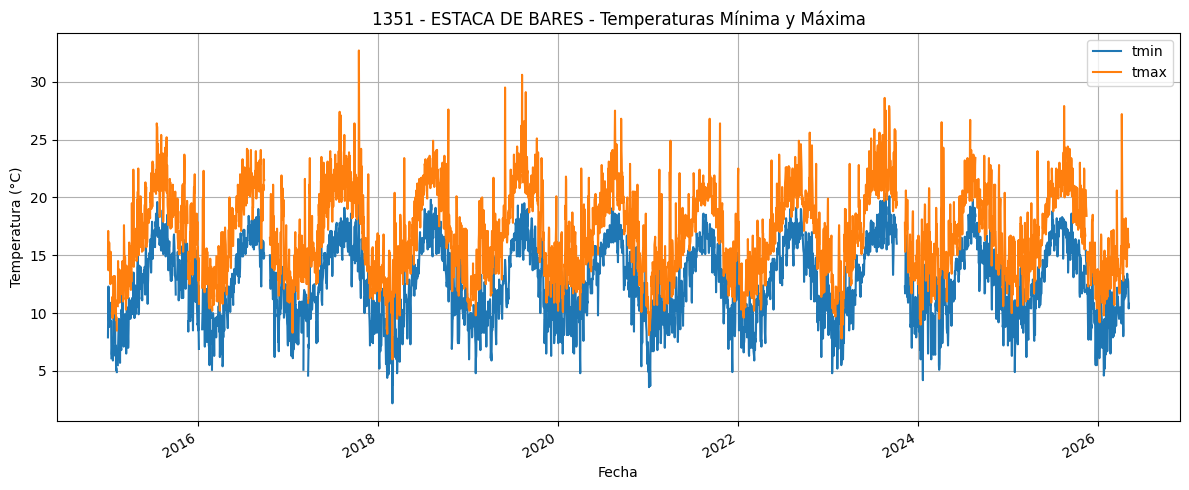

In [22]:
station_id = "1351"

locations_dict = os.path.join(JSON_DIR, "locations.json")
with open(locations_dict, "r", encoding="utf-8") as f:
    locations = json.load(f)

station_name = locations.get(station_id, station_id)

station_plot_df = pd.read_csv(os.path.join(CSV_DIR, f"{station_id}_hist.csv"))
schema_path = os.path.join(JSON_DIR, "data-fields.json")
station_plot_df = cast_columns(station_plot_df, schema_path)

ax = station_plot_df.sort_values("fecha").plot(x="fecha", y=["tmin", "tmax"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"{station_id} - {station_name} - Temperaturas Mínima y Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()

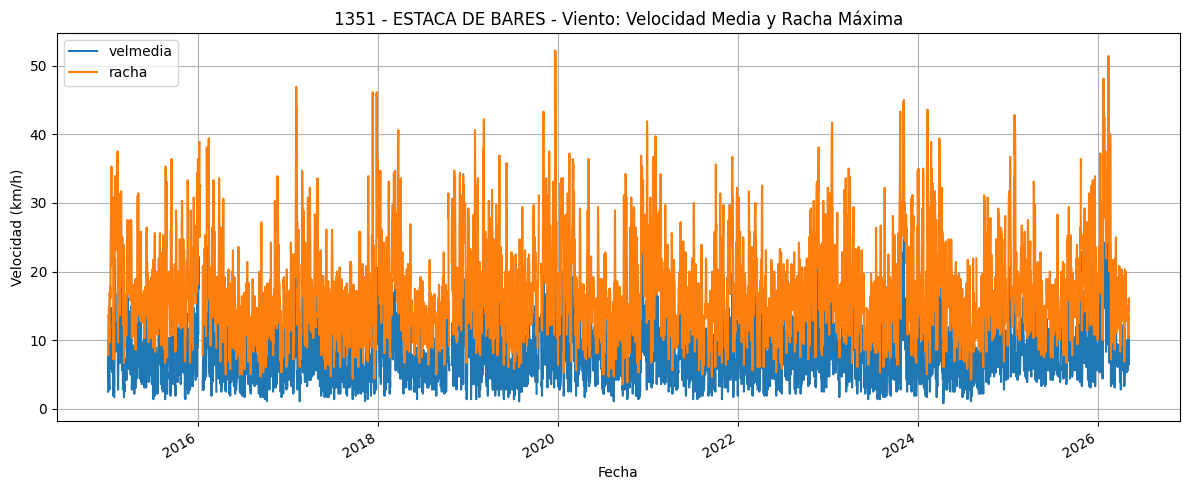

In [23]:
ax = station_plot_df.sort_values("fecha").plot(x="fecha", y=["velmedia", "racha"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Velocidad (km/h)")
ax.set_title(f"{station_id} - {station_name} - Viento: Velocidad Media y Racha Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()

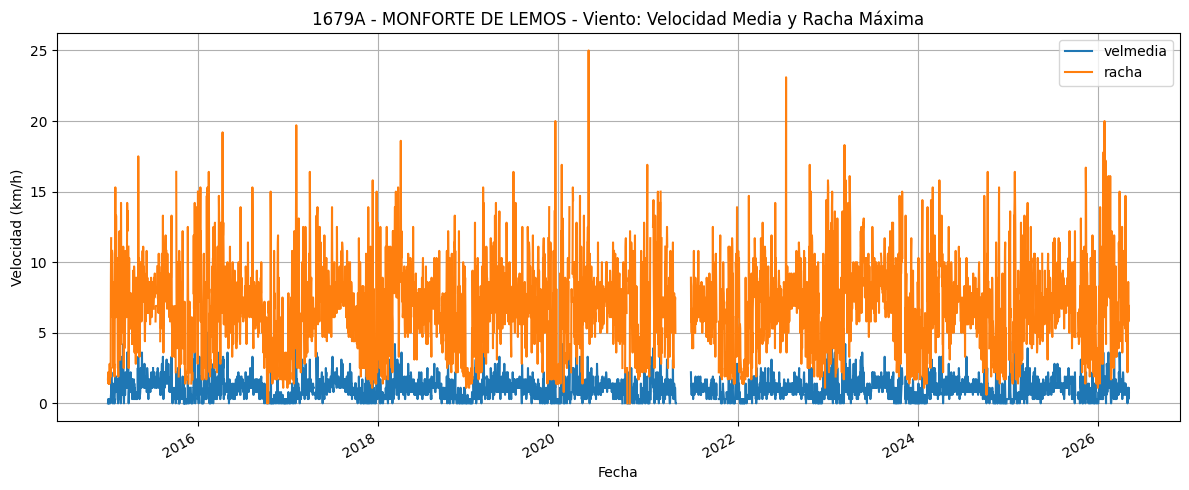

In [24]:
station_id = "1679A"

locations_dict = os.path.join(JSON_DIR, "locations.json")
with open(locations_dict, "r", encoding="utf-8") as f:
    locations = json.load(f)

station_name = locations.get(station_id, station_id)

station_plot_df = pd.read_csv(os.path.join(CSV_DIR, f"{station_id}_hist.csv"))
schema_path = os.path.join(JSON_DIR, "data-fields.json")
station_plot_df = cast_columns(station_plot_df, schema_path)

ax = station_plot_df.sort_values("fecha").plot(x="fecha", y=["velmedia", "racha"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Velocidad (km/h)")
ax.set_title(f"{station_id} - {station_name} - Viento: Velocidad Media y Racha Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()

### Maps

In [26]:
stations_df = pd.read_csv(os.path.join(STATS_DIR, "weather-station-stats.csv"))

meta_path = os.path.join(JSON_DIR, "location-metadata.json")
with open(meta_path, "r", encoding="utf-8") as f:
    loc_meta = json.load(f)

stations_df["lon"] = stations_df["indicativo"].map(lambda k: loc_meta.get(k, {}).get("lon"))
stations_df["lat"] = stations_df["indicativo"].map(lambda k: loc_meta.get(k, {}).get("lat"))

stations_df["lon"] = pd.to_numeric(stations_df["lon"], errors="coerce")
stations_df["lat"] = pd.to_numeric(stations_df["lat"], errors="coerce")

stations_df.sample(5)

,indicativo,nombre,altitud,provincia,num_records,avg_tmin,avg_tmax,avg_prec,avg_velmedia,std_tmed,longest_gap_days,lon,lat
130,1521X,BECERREÁ,1080,LUGO,4009,6.789126,14.392884,4.084992,2.346142,5.909522,3,-7.185170,42.863768
3,0042Y,TARRAGONA,55,TARRAGONA,4001,13.231322,22.422759,1.266323,1.716104,5.690694,10,1.249167,41.123892
166,2192C,CUÉLLAR,795,SEGOVIA,4011,3.179156,20.857859,1.262075,2.567183,6.895150,6,-4.265450,41.383553
401,5702X,CARMONA,50,SEVILLA,3950,12.569070,26.303992,1.230095,2.851461,6.722788,22,-5.740475,37.565485
246,3130C,SIGÜENZA,1005,GUADALAJARA,3827,4.001512,18.755426,1.312442,1.823019,6.899004,29,-2.617927,41.086277


#### Average minimum temperatures maps

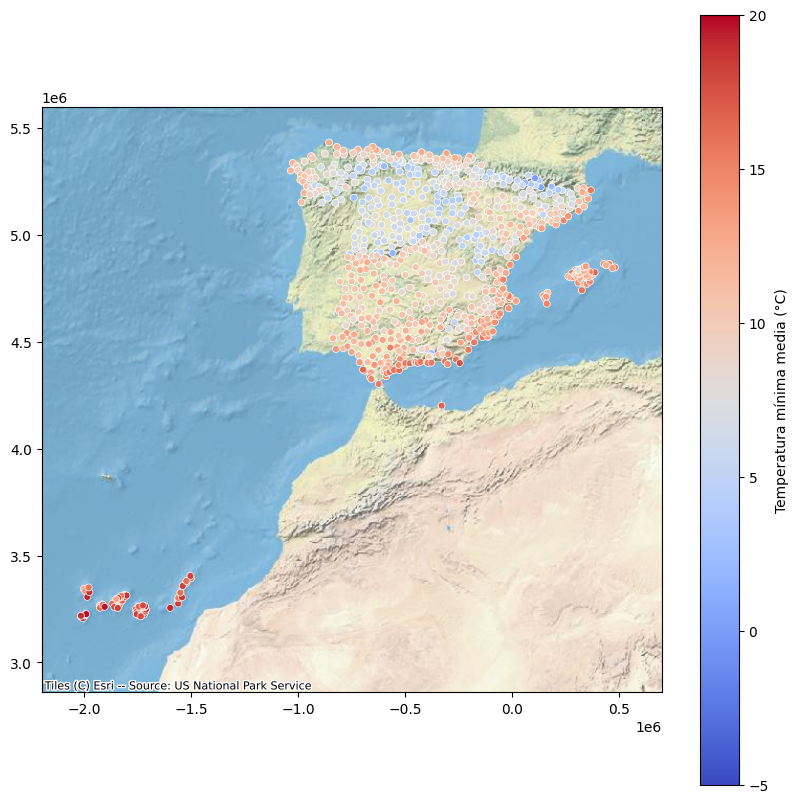

In [27]:
low_threshold = -5
high_threshold = 20

gdf = gpd.read_file(os.path.join(MAPS_DIR, "ne_110m_admin_0_countries.gpkg"))
sample_locations = stations_df.copy()

sample_points = gpd.GeoDataFrame(
    sample_locations.copy(),
    geometry=gpd.points_from_xy(sample_locations["lon"], sample_locations["lat"]),
    crs=4326,
).to_crs(epsg=3857)

ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')

sample_points.plot(
    ax=ax,
    column='avg_tmin',
    cmap='coolwarm',
    vmin=low_threshold,
    vmax=high_threshold,
    markersize=25,
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgray', 'edgecolor': 'white'}
)

ax.set_xlim([-2200000, 700000])
ax.set_ylim([2860000, 5600000])

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldPhysical)

sm = plt.cm.ScalarMappable(norm=Normalize(vmin=low_threshold, vmax=high_threshold), cmap='coolwarm')
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Temperatura mínima media (°C)")

plt.show()

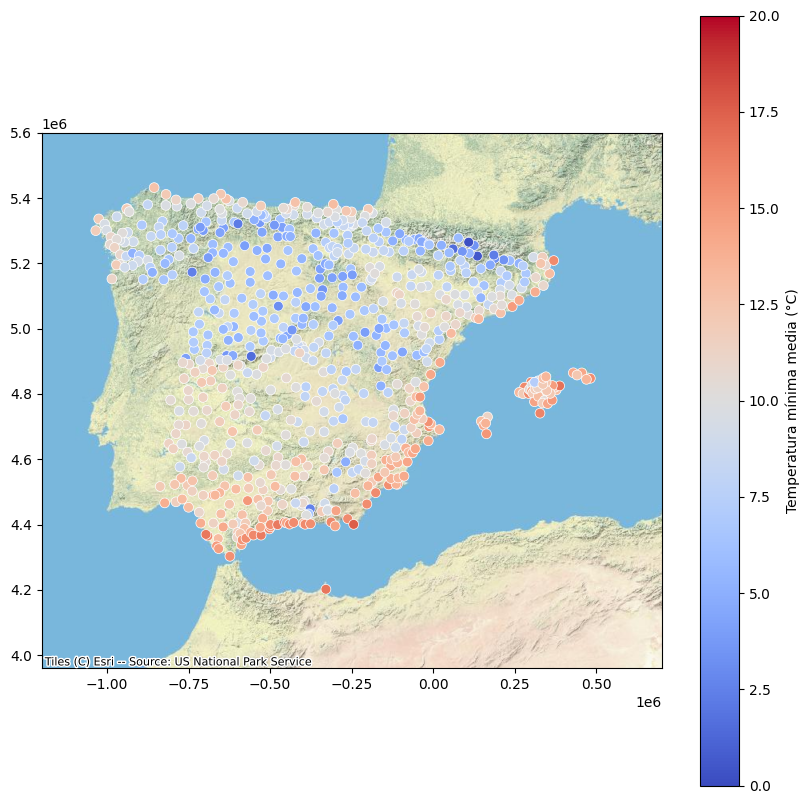

In [28]:
low_threshold = 0
high_threshold = 20

gdf = gpd.read_file(os.path.join(MAPS_DIR, "ne_110m_admin_0_countries.gpkg"))
sample_locations = stations_df.copy()

sample_points = gpd.GeoDataFrame(
    sample_locations.copy(),
    geometry=gpd.points_from_xy(sample_locations["lon"], sample_locations["lat"]),
    crs=4326,
).to_crs(epsg=3857)

ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')

sample_points.plot(
    ax=ax,
    column='avg_tmin',
    cmap='coolwarm',
    vmin=low_threshold,
    vmax=high_threshold,
    markersize=50,
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgray', 'edgecolor': 'white'}
)

ax.set_xlim([-1200000, 700000])
ax.set_ylim([3960000, 5600000])

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldPhysical)

sm = plt.cm.ScalarMappable(norm=Normalize(vmin=low_threshold, vmax=high_threshold), cmap='coolwarm')
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Temperatura mínima media (°C)")

plt.show()

#### Average precipitation maps

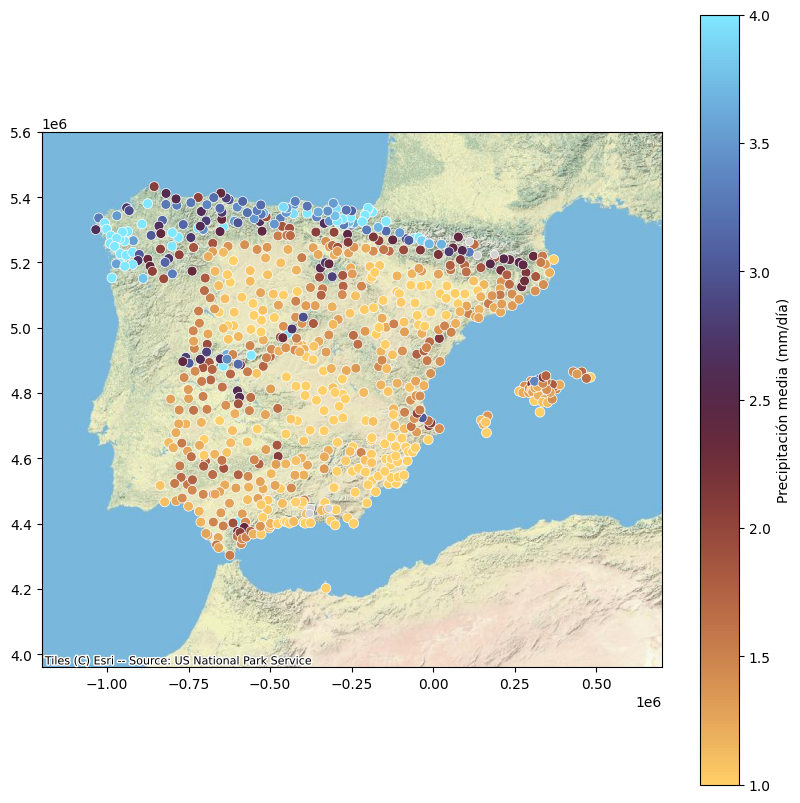

In [31]:
low_threshold = 1
high_threshold = 4

gdf = gpd.read_file(os.path.join(MAPS_DIR, "ne_110m_admin_0_countries.gpkg"))
sample_locations = stations_df.copy()

sample_points = gpd.GeoDataFrame(
    sample_locations.copy(),
    geometry=gpd.points_from_xy(sample_locations["lon"], sample_locations["lat"]),
    crs=4326,
).to_crs(epsg=3857)

ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')

sample_points.plot(
    ax=ax,
    column='avg_prec',
    cmap='managua',
    vmin=low_threshold,
    vmax=high_threshold,
    markersize=50,
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgray', 'edgecolor': 'white'}
)

ax.set_xlim([-1200000, 700000])
ax.set_ylim([3960000, 5600000])

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldPhysical)

sm = plt.cm.ScalarMappable(norm=Normalize(vmin=low_threshold, vmax=high_threshold), cmap='managua')
sm.set_array([])

plt.colorbar(sm, ax=ax, label="Precipitación media (mm/día)")

plt.show()